In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from Data_Loader import DataLoader       # استدعاء الكلاس المسئول عن تحميل البيانات
from Data_Inspector import DataInspector # استدعاء الكلاس المجمع للـ EDA
# استدعاء المسارات وتحميل البيانات
from config import TRAIN_PATH, TEST_PATH
from housing_cleaning import remove_training_outliers

In [7]:
# 1. إظهار كافة الأعمدة أفقياً بدون اختصار (...)
pd.set_option('display.max_columns', None)

# 2. تحديد عدد الصفوف المعروضة ليكون 30 صفوف فقط لتقليل الطول
pd.set_option('display.max_rows', 82)

In [8]:
loader = DataLoader(TRAIN_PATH, TEST_PATH)
train_df, test_df = loader.load_all_data()

# إنشاء كائن الـ DataInspector
inspector = DataInspector(train_df)

In [9]:
train_df = remove_training_outliers(train_df)

In [10]:
# تطبيق Log Transformation على سعر البيع في train_df
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

# إعادة تحديث الـ inspector بالبيانات الجديدة عشان الـ EDA والـ Correlation الجايين
inspector = DataInspector(train_df)


In [11]:
inspector.numeric_df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,12.247699
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,12.109016
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,12.317171
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,11.849405
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448,1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,953,953,953,694,0,1647,0,0,2,1,3,1,7,1,1999.0,2,460,0,40,0,0,0,0,0,8,2007,12.072547
1449,1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,589,1542,2073,0,0,2073,1,0,2,0,3,1,7,2,1978.0,2,500,349,0,0,0,0,0,0,2,2010,12.254868
1450,1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,877,1152,1188,1152,0,2340,0,0,2,0,4,1,9,2,1941.0,1,252,0,60,0,0,0,0,2500,5,2010,12.493133
1451,1459,20,68.0,9717,5,6,1950,1996,0.0,49,1029,0,1078,1078,0,0,1078,1,0,1,0,2,1,5,0,1950.0,1,240,366,0,112,0,0,0,0,4,2010,11.864469


In [12]:
inspector.cat_df

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,NaN,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,NaN,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,NaN,TA,TA,PConc,Gd,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1449,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,Plywood,Plywood,Stone,TA,TA,CBlock,Gd,TA,No,ALQ,Rec,GasA,TA,Y,SBrkr,TA,Min1,TA,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1450,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,CemntBd,CmentBd,NaN,Ex,Gd,Stone,TA,Gd,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1451,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,TA,TA,Mn,GLQ,Rec,GasA,Gd,Y,FuseA,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [13]:
inspector.get_summary()

=== Dataset Dimensions ===
Rows: 1453 | Columns: 81

=== Data Types Breakdown ===
object     43
int64      34
float64     4
Name: count, dtype: int64

=== Detailed Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1453 non-null   int64  
 1   MSSubClass     1453 non-null   int64  
 2   MSZoning       1453 non-null   object 
 3   LotFrontage    1195 non-null   float64
 4   LotArea        1453 non-null   int64  
 5   Street         1453 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1453 non-null   object 
 8   LandContour    1453 non-null   object 
 9   Utilities      1453 non-null   object 
 10  LotConfig      1453 non-null   object 
 11  LandSlope      1453 non-null   object 
 12  Neighborhood   1453 non-null   object 
 13  Condition1     1453 non-null   object 
 14  Cond

In [14]:
inspector.check_duplicates()

Total Duplicate Rows: 0 (0.00%)
No duplicate rows found.


np.int64(0)

In [15]:
# 2. تشغيل الفحص الشامل دفعة واحدة (بضغطة زرار)
inspection_summary = inspector.run_full_inspection(target_col="SalePrice")

###  Missing

,Missing Count,Percentage (%)
PoolQC,1447,99.587061
MiscFeature,1400,96.352374
Alley,1362,93.737096
Fence,1172,80.660702
MasVnrType,871,59.944942
FireplaceQu,689,47.419133
LotFrontage,258,17.756366
GarageType,81,5.574673
GarageYrBlt,81,5.574673
GarageFinish,81,5.574673


###  High Missing

,Missing Count,Percentage (%)
PoolQC,1447,99.587061
MiscFeature,1400,96.352374
Alley,1362,93.737096
Fence,1172,80.660702
MasVnrType,871,59.944942
FireplaceQu,689,47.419133


###  Skewed Features

,Feature,Skewness
0,MiscVal,24.446859
1,PoolArea,15.921308
2,LotArea,12.628457
3,3SsnPorch,10.278995
4,LowQualFinSF,8.988970
5,KitchenAbvGr,4.476086
6,BsmtFinSF2,4.295802
7,ScreenPorch,4.134746
8,BsmtHalfBath,4.091881
9,EnclosedPorch,3.080384


###  Outliers

,Feature,Total Outliers,Mild Count (1.5x),Mild (%),Lower Bound,Upper Bound,Extreme Count (3.0x),Extreme (%),Ext. Lower Bound,Ext. Upper Bound
0,OverallCond,125,124,8.53,3.50,7.50,1,0.07,2.00,9.00
1,MSSubClass,102,102,7.02,-55.00,145.00,0,0.00,-130.00,220.00
2,MasVnrArea,96,70,4.82,-246.00,410.00,26,1.79,-492.00,656.00
3,LotFrontage,85,74,5.09,27.50,111.50,11,0.76,-4.00,143.00
4,OpenPorchSF,75,59,4.06,-102.00,170.00,16,1.10,-204.00,272.00
5,LotArea,68,37,2.55,1508.00,17580.00,31,2.13,-4519.00,23607.00
6,TotalBsmtSF,58,57,3.92,48.00,2040.00,1,0.07,-699.00,2787.00
7,BedroomAbvGr,35,34,2.34,0.50,4.50,1,0.07,-1.00,6.00
8,WoodDeckSF,31,28,1.93,-252.00,420.00,3,0.21,-504.00,672.00
9,GrLivArea,29,27,1.86,156.00,2748.00,2,0.14,-816.00,3720.00


###  Feature Classification

,Feature,DataType,Unique Values,Classification
0,Id,int64,1453,Quantitative - Continuous
1,MSSubClass,int64,15,Quantitative - Discrete
2,MSZoning,object,5,Qualitative - Nominal
3,LotFrontage,float64,110,Quantitative - Continuous
4,LotArea,int64,1066,Quantitative - Continuous
5,Street,object,2,Qualitative - Nominal
6,Alley,object,2,Qualitative - Nominal
7,LotShape,object,4,Qualitative - Nominal
8,LandContour,object,4,Qualitative - Nominal
9,Utilities,object,2,Qualitative - Nominal


In [16]:
inspector.describe_numerical()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1453.000000,1453.000000,1195.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1445.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1372.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000,1453.000000
mean,730.280798,56.896077,69.689540,10434.504474,6.092223,5.579491,1971.177564,1984.818995,102.451211,437.549897,46.072953,565.320028,1048.942877,1156.927736,346.951824,5.872677,1509.752237,0.423262,0.057811,1.563661,0.382657,2.867171,1.046800,6.507226,0.609773,1978.393586,1.761184,469.857536,94.105988,46.279422,22.059876,3.426015,15.016518,2.441844,43.313145,6.322092,2007.814178,12.023024
std,421.848891,42.218940,23.155649,9856.204679,1.369594,1.113426,30.187182,20.630613,179.558010,431.213944,160.766493,440.011073,407.441061,370.049386,435.699174,48.738447,507.746331,0.517393,0.239294,0.550082,0.502914,0.817072,0.220845,1.615433,0.641613,24.688482,0.743257,208.615741,125.141583,65.385562,61.247240,29.386956,55.735130,38.275411,497.124823,2.700278,1.329841,0.398307
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,10.460271
25%,365.000000,20.000000,59.000000,7535.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.000000,882.000000,0.000000,0.000000,1128.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,328.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,11.774528
50%,731.000000,50.000000,69.000000,9453.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,381.000000,0.000000,474.000000,990.000000,1086.000000,0.000000,0.000000,1458.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,478.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,12.001512
75%,1095.000000,70.000000,80.000000,11553.000000,7.000000,6.000000,2000.000000,2004.000000,164.000000,706.000000,0.000000,806.000000,1293.000000,1383.000000,728.000000,0.000000,1776.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,12.273736
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,2188.000000,1474.000000,2336.000000,3200.000000,3228.000000,2065.000000,572.000000,4476.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1220.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,13.534474


In [17]:
inspector.describe_categorical()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1453,1453,91,1453,1453,1453,1453,1453,1453,1453,1453,1453,1453,1453,1453,1453,1453,582,1453,1453,1453,1416,1416,1415,1416,1416,1453,1453,1453,1452,1453,1453,764,1372,1372,1372,1372,1453,6,281,53,1453,1453
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,7,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,1145,1448,50,921,1308,1452,1046,1376,225,1255,1439,1214,721,1138,1428,512,501,443,905,1276,642,647,1304,950,428,1251,1421,735,1358,1327,733,1353,375,866,605,1304,1319,1333,2,157,48,1264,1194


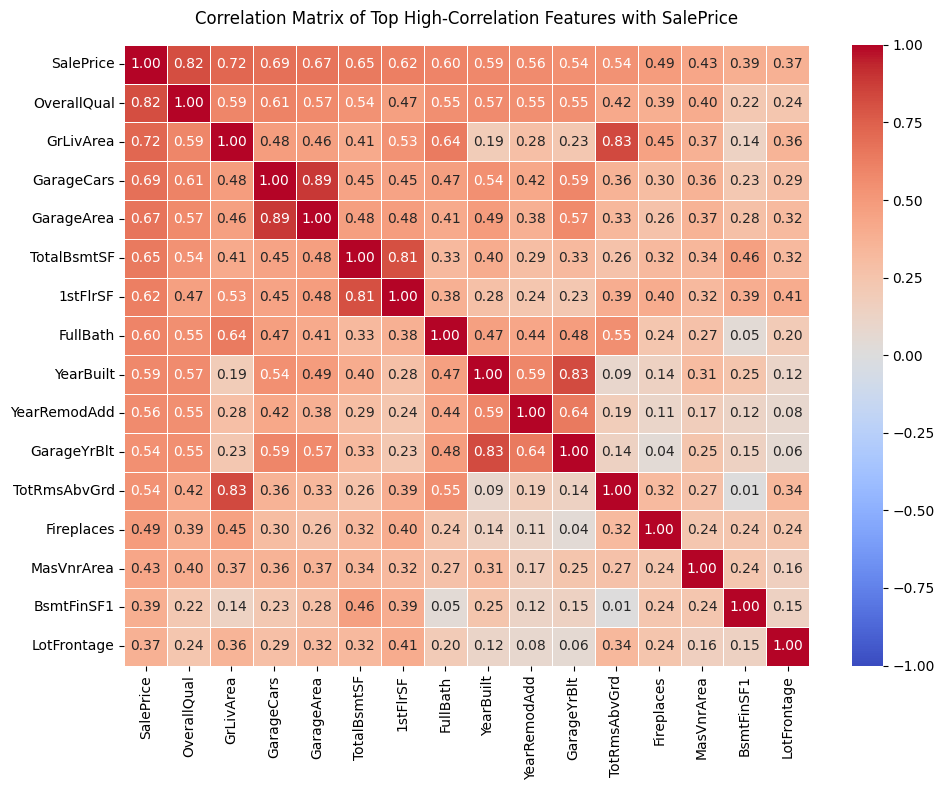

In [18]:
inspector.get_top_correlations()

In [19]:
inspector.get_high_numerical_correlations()

,Feature 1,Feature 2,Correlation
0,GarageArea,GarageCars,0.889
1,TotRmsAbvGrd,GrLivArea,0.829
2,GarageYrBlt,YearBuilt,0.826
3,SalePrice,OverallQual,0.820
4,1stFlrSF,TotalBsmtSF,0.805
5,SalePrice,GrLivArea,0.724
6,GrLivArea,2ndFlrSF,0.698
7,SalePrice,GarageCars,0.685
8,TotRmsAbvGrd,BedroomAbvGr,0.683
9,SalePrice,GarageArea,0.670


In [20]:
inspector.get_categorical_summary()

,Feature,Unique Classes,Missing Count,Missing (%),Top Class,Top Frequency,Top Dominance (%)
0,Neighborhood,25,0,0.00,NAmes,225,15.49
1,Exterior2nd,16,0,0.00,VinylSd,501,34.48
2,Exterior1st,15,0,0.00,VinylSd,512,35.24
3,Condition1,9,0,0.00,Norm,1255,86.37
4,SaleType,9,0,0.00,WD,1264,86.99
5,HouseStyle,8,0,0.00,1Story,721,49.62
6,Condition2,8,0,0.00,Norm,1439,99.04
7,RoofMatl,7,0,0.00,CompShg,1428,98.28
8,Functional,7,0,0.00,Typ,1353,93.12
9,BsmtFinType2,6,37,2.55,Unf,1251,86.10


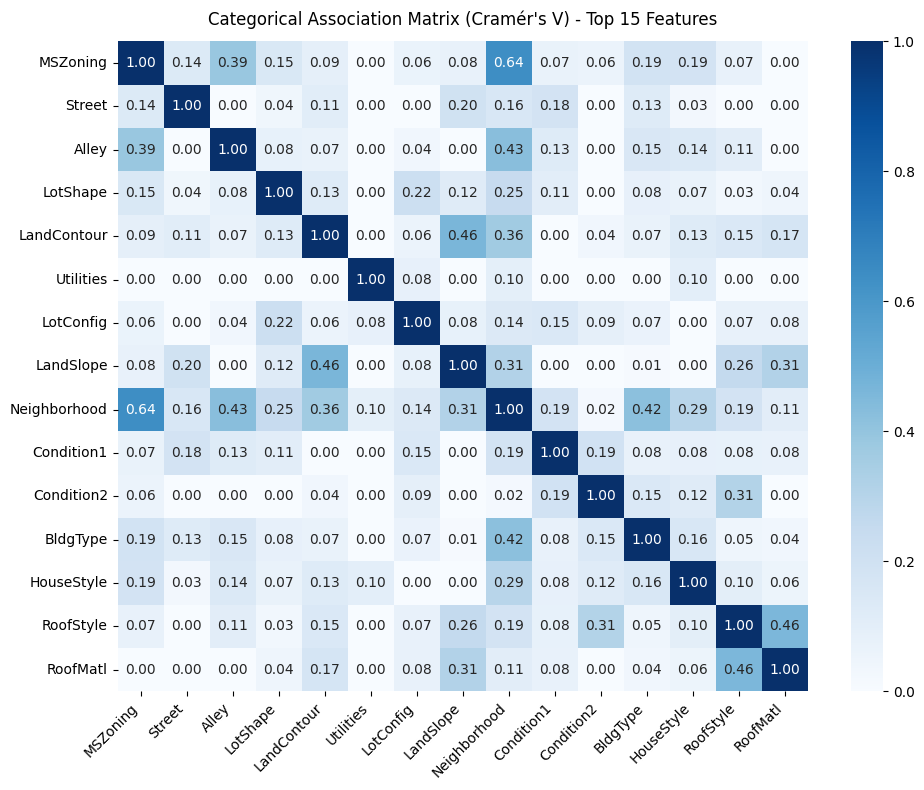

,Feature 1,Feature 2,Cramer's V
0,Exterior1st,Exterior2nd,0.758
1,GarageQual,GarageCond,0.704
2,GarageType,GarageFinish,0.685
3,MSZoning,Neighborhood,0.637
4,GarageFinish,GarageQual,0.589
5,GarageFinish,GarageCond,0.586
6,BsmtQual,BsmtFinType1,0.576
7,ExterQual,KitchenQual,0.541
8,Foundation,BsmtQual,0.531
9,BsmtQual,BsmtCond,0.527


In [21]:
inspector.get_categorical_correlation()

In [22]:
inspector.get_categorical_vs_numerical_correlation()

,Feature,F-Statistic,p-value,Is Significant
0,ExterQual,414.40,2.494430e-194,True
1,KitchenQual,392.44,1.537042e-186,True
2,BsmtQual,364.13,3.942373e-175,True
3,GarageFinish,330.63,7.077212e-118,True
4,CentralAir,206.32,7.625306e-44,True
5,HeatingQC,144.83,4.526486e-82,True
6,Foundation,125.67,1.175973e-110,True
7,GarageType,100.61,1.868998e-90,True
8,Neighborhood,78.63,9.632530e-241,True
9,MSZoning,76.53,6.346983e-59,True


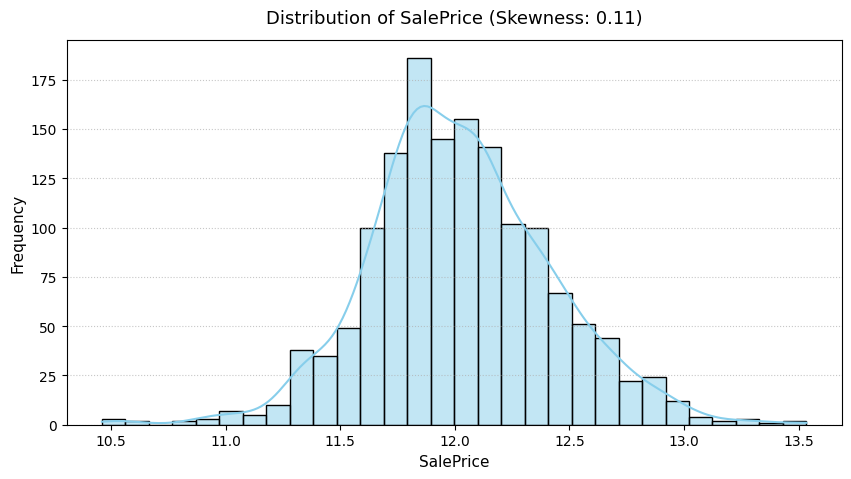

In [23]:
inspector.plot_numerical_distribution('SalePrice')

In [24]:
#Read the data description and make groups for the features relate to each other

**Begining of the clean data decions**

Delete "PoolQC" column

c:\Users\Belal Moustafa\Desktop\Machine Learning\Kaggle\Housing Prices\Data_Inspector\categorical_mixin.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=column_name, order=order, palette="viridis")


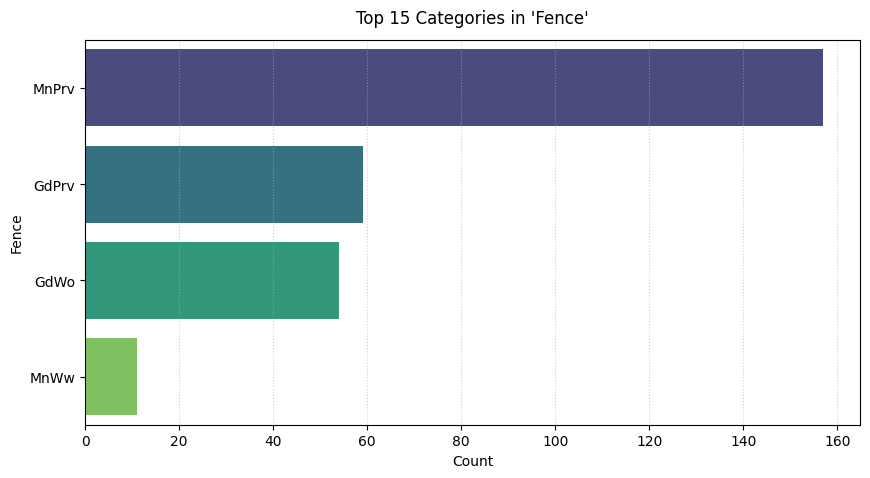

c:\Users\Belal Moustafa\Desktop\Machine Learning\Kaggle\Housing Prices\Data_Inspector\categorical_mixin.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x=feature_col, y=target_col, order=sorted_order, palette="Set2", showfliers=False)


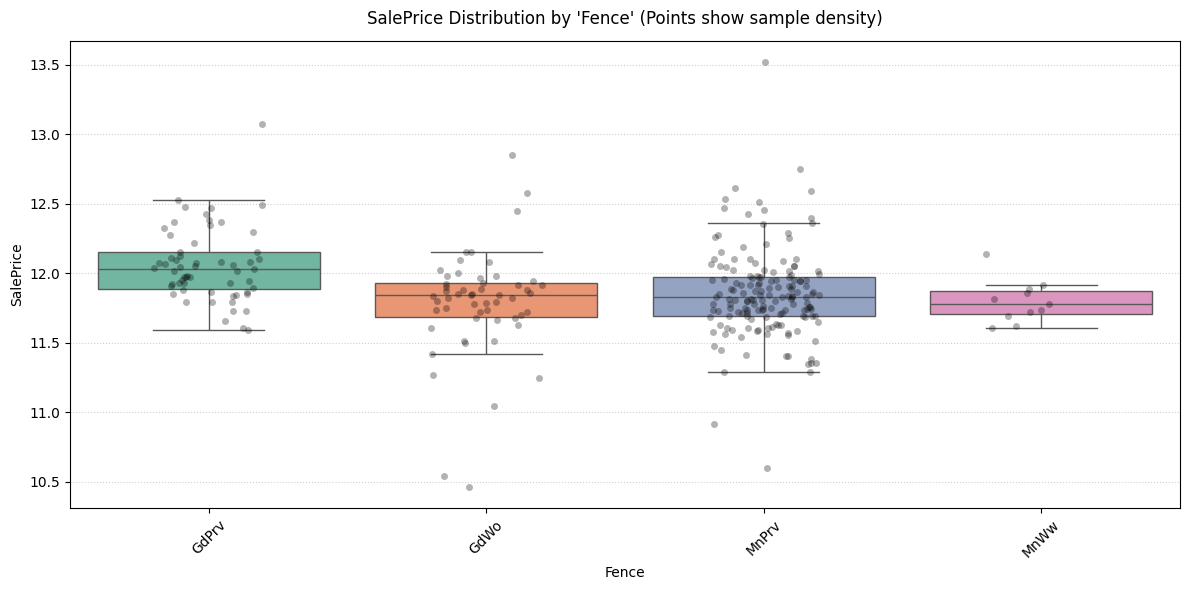

In [25]:
inspector.profile_column('Fence', target_col='SalePrice')


c:\Users\Belal Moustafa\Desktop\Machine Learning\Kaggle\Housing Prices\Data_Inspector\categorical_mixin.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=column_name, order=order, palette="viridis")


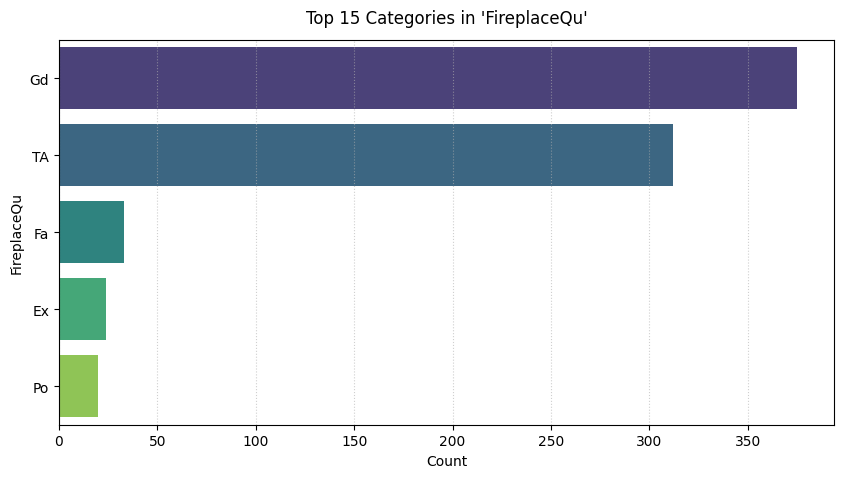

c:\Users\Belal Moustafa\Desktop\Machine Learning\Kaggle\Housing Prices\Data_Inspector\categorical_mixin.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x=feature_col, y=target_col, order=sorted_order, palette="Set2", showfliers=False)


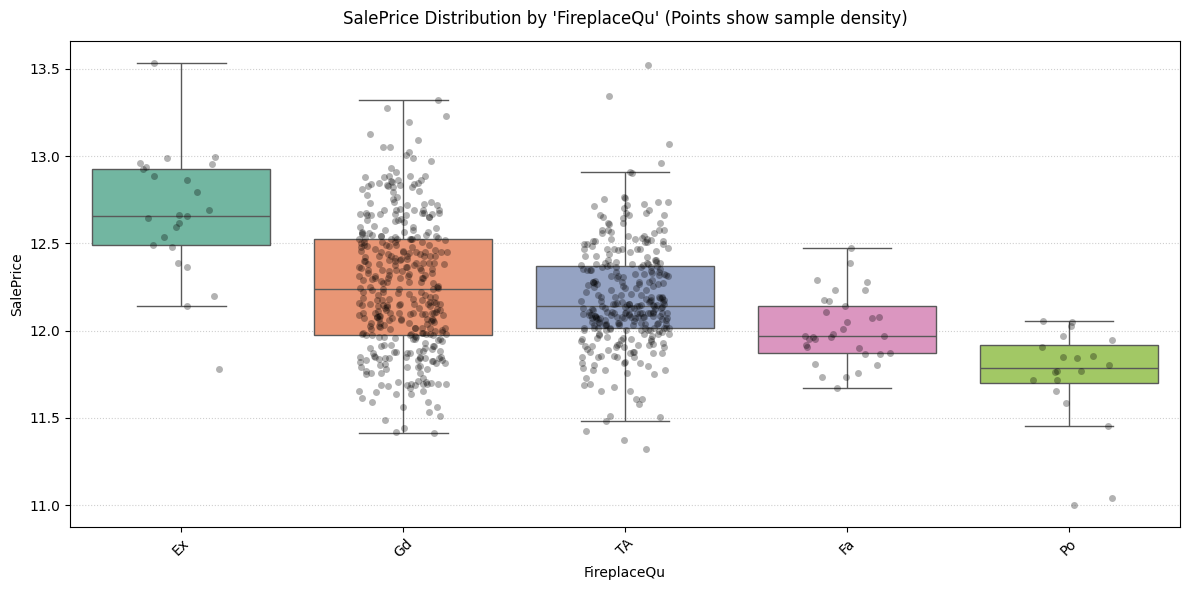

In [26]:
inspector.profile_column('FireplaceQu', target_col='SalePrice')
